# Deep Learning for finance
## Deep hedging session: hands-on with Keras and Tensorflow

Stefano De Marco

<br>

This notebook is an introduction and a warm-up: it is intended to illustrate, with a simple learning task of a one dimensional sinusoidal function, how deep models can be built using Keras (using Tensorflow as a backend). We will then use the same code structure for our deep hedging problem, in a second notebook.

In [1]:
import numpy as np
import tensorflow as tf

from keras import initializers

import matplotlib.pyplot as plt

I0000 00:00:1773052433.291205   10069 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773052433.354604   10069 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773052435.999853   10069 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
# Definition of the neural network layers

m = 1  # dimension of the input (in the deep hedging problem, this will be the dimension of the underlying asset price)
d = 2  # number of layers in the NN (including the output layer)
n = (
    2**12
)  # nodes in the first but last layers (the last layer has the desired output dimension. In the deep hedging problem: dimension of the delta function)

###################################
# Done.
###################################
layers = []
for i in range(d):
    if i < d - 1:
        nodes = n
        layer = tf.keras.layers.Dense(
            units=nodes,
            activation="relu",
            trainable=True,  # units: the dimension of this layer's output
            kernel_initializer=initializers.RandomNormal(0, 1),  # type: ignore
            bias_initializer=initializers.RandomUniform(-1, 1),  # type: ignore
            name=str(i),
        )
    else:
        nodes = m
        layer = tf.keras.layers.Dense(
            units=nodes,
            activation="linear",
            trainable=True,
            kernel_initializer=initializers.RandomNormal(0, 1 / n),  # type: ignore
            bias_initializer=initializers.RandomUniform(0, 0),  # type: ignore
            name=str(i),
        )
    layers = layers + [
        layer
    ]  # this variable "layers" is simply a list of Keras tensors

In [5]:
###################################################
# Implementing the neural network from its layers
###################################################
# The input values will be contained the training set defined in the cell below (a vector xtrain)
input = tf.keras.Input(shape=(m,))

our_output = input
for k in range(d):
    our_output = layers[k]( our_output )  # here we implement the composition of the layers defining the whole NN

deep_model = tf.keras.models.Model(inputs = input , outputs = our_output )

E0000 00:00:1773052578.058970   10069 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
deep_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0 (Dense)                       │ (None, 4096)           │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1 (Dense)                       │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Let us define our data set and the target function (simply a sinusoidal function on the real line).

/tmp/ipykernel_10069/3637418627.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


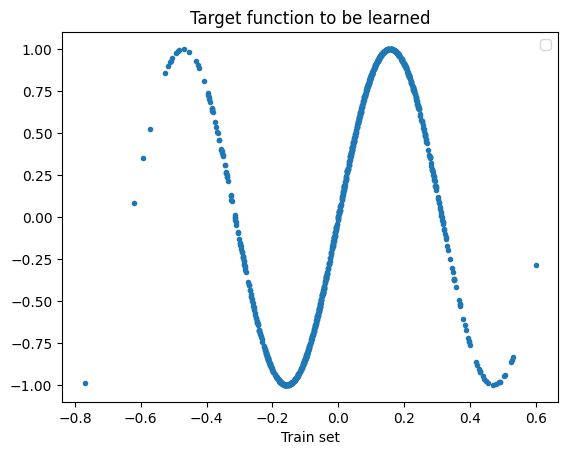

In [7]:
N_train = 10**3

xtrain = np.random.normal(loc=0, scale=0.2, size=(N_train,1))

ytrain = np.sin(10*xtrain) + np.random.normal(loc=0, scale=0.0, size=(N_train,1))

###########################################################
## Let us plot the target function over the training set
###########################################################
plt.plot(xtrain, ytrain, '.',)
plt.title("Target function to be learned")
plt.xlabel("Train set")
plt.legend(loc="best")

Let us plot the initial (random) configuration of the neural network.



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


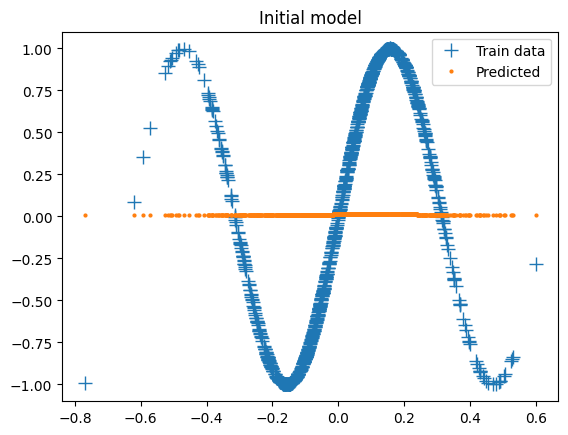

In [8]:
plt.plot(xtrain, ytrain,'+', markersize="10", label="Train data")

plt.plot(xtrain, deep_model.predict( xtrain ), '.', markersize="4", label="Predicted")

plt.title("Initial model")
plt.legend(loc="best")
plt.show()

In the cell below, we compile the deep model using a choice of loss function and an optimizer (for the optimization of the network parameters).

In [9]:
opt = tf.keras.optimizers.SGD(learning_rate=1.e-4)

deep_model.compile(optimizer = opt, loss='mean_squared_error')

Here we launch the model training.

In [10]:
deep_model.fit(x = xtrain, y = ytrain, epochs=20, verbose=True, batch_size=5)  # type: ignore

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.4222
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 0.3912
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 0.3752
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3619
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - loss: 0.3492
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - loss: 0.3351
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3214
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 0.3095
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.2990
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 0.2872
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.2753
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - loss: 0.2672
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - loss: 0.2582
Epoch 14/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - loss: 0.2448
Epoch 15/20
200/200 ━━━━━━━━━━━━━

With the configuration above, the training should be pretty quick (a few seconds).

Let us display the performances of the resulting model on the train set.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


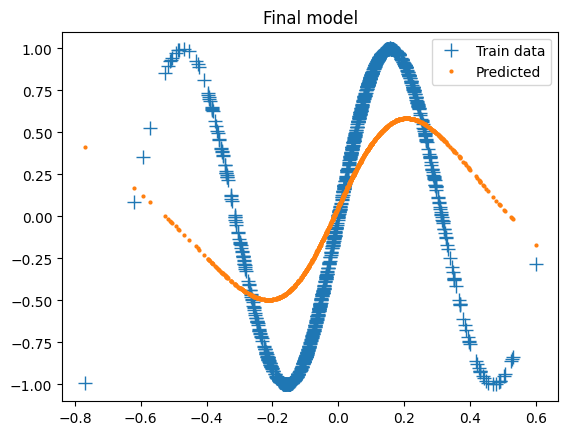

In [ ]:
plt.plot(xtrain, ytrain, "+", markersize="10", label="Train data")

plt.plot(xtrain, deep_model.predict(xtrain), ".", markersize="4", label="Predicted")

plt.title("Final model")
plt.legend(loc = "best")
plt.show()

 Let us now display the performances of the resulting model on a test set that slightly extends the train set.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step


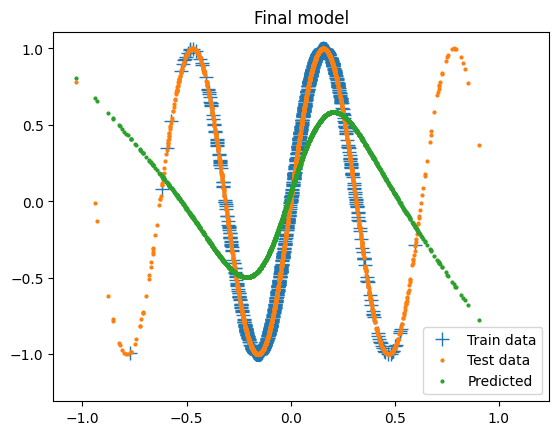

In [ ]:
N_test = 2 * 10**3

xtest = np.random.normal(0, 0.3, (N_test, 1))
ytest = np.sin(10 * xtest)

plt.plot(xtrain, ytrain, "+", markersize="10", label="Train data")

plt.plot(xtest, ytest, ".", markersize="4", label="Test data")

plt.plot(xtest, deep_model.predict(xtest), ".", markersize="4", label="Predicted")

plt.title("Final model")
plt.legend(loc="best")
plt.show()